# nb_full_03 — Ablation Study: What Makes Domain Generalisation Work?

**Goal:** Isolate the contribution of each design decision in TropiCycloneNet's DG training.

Key findings from `nb_full_02`:
- **NI** is severely data-starved (28 test samples, in-domain val-loss = 74) — best DG stress-test
- **WP** is the universal donor basin — most transferable across all targets
- Track ADE is unreliable at 5 epochs (>8000 km) — focus on IntAcc, DirAcc, WindMAE

**Five ablation axes:**
1. **DG Method** — ERM vs IRM vs VREx vs CORAL vs DANN vs PhysIRM
2. **Source Basin Composition** — LOBO (all 5) vs greedy-optimal subset (from nb_full_02)
3. **Input Modality** — remove 3D spatial or Env-Data from PhysIRM
4. **PhysIRM Components** — zero out λ_irm / λ_orth / λ_phys one at a time
5. **λ Sensitivity** — sweep each PhysIRM hyperparameter

All ablations: train years 2017–2020, evaluate on 2022–2023. Primary target: **NI**. Secondary: **SI**.


In [1]:
# -- Setup ------------------------------------------------------------------
import subprocess, sys, importlib, os
from pathlib import Path

subprocess.run([sys.executable, "-m", "pip", "install", "seaborn", "netCDF4", "tqdm", "-q"],
               capture_output=True)

TOKEN = ""
REPO  = f"https://{TOKEN}@github.com/Thiruvikraman07/ClimateChangeFinalProject.git"
ROOT  = Path("/content/ClimateChangeFinalProject")
if not ROOT.exists():
    subprocess.run(["git", "clone", REPO, str(ROOT)], check=True)
else:
    subprocess.run(["git", "-C", str(ROOT), "pull"], check=True)

if str(ROOT / "final_src") not in sys.path:
    sys.path.insert(0, str(ROOT / "final_src"))
os.chdir(ROOT)

for _k in list(sys.modules.keys()):
    if _k.startswith(("dataset","models","methods","metrics","configs")):
        del sys.modules[_k]

from google.colab import drive
drive.mount("/content/drive")

DATA_ROOT = Path("/content/drive/MyDrive/MLfTCC/Data/Tropicyclonenet/TestData/TCND_test")

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.optim as optim, time, copy as _copy
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader as _DL

import dataset.dataset, models.backbone, methods.dg_methods, metrics.basin_metrics
importlib.reload(dataset.dataset); importlib.reload(models.backbone)
importlib.reload(methods.dg_methods); importlib.reload(metrics.basin_metrics)

from dataset.dataset import BASIN_CODES, TCNDDataset, tcnd_collate_fn
from models.backbone import TropiCycloneModel
from methods.dg_methods import build_method, task_loss as _task_loss
from metrics.basin_metrics import BasinEvaluator

BASINS = BASIN_CODES
DEVICE = (torch.device("cuda") if torch.cuda.is_available()
          else torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cpu"))
print(f"Device : {DEVICE}")
print(f"Basins : {BASINS}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
Basins : ['WP', 'NA', 'EP', 'NI', 'SI', 'SP']


In [2]:
# -- Prefetch Drive -> local SSD --------------------------------------------
from dataset.dataset import prefetch_to_local
LOCAL_SSD = Path("/content/tcnd_local")

if (LOCAL_SSD / "Data1D").exists():
    LOCAL_ROOT = str(LOCAL_SSD)
    print(f"Local SSD already populated.\nLOCAL_ROOT = {LOCAL_ROOT}")
else:
    _d1d  = Path(DATA_ROOT) / "Data1D"
    _hits = list(Path(DATA_ROOT).rglob("Data1D")) if not _d1d.exists() else [_d1d]
    _d1d  = _hits[0] if _hits else _d1d
    _votes = []
    for _b in BASINS:
        _bd = _d1d / _b
        if _bd.exists():
            for _p in ["train", "val", "test"]:
                if (_bd / _p).exists(): _votes.append(_p); break
    from collections import Counter as _Ctr
    _split = _Ctr(_votes).most_common(1)[0][0] if _votes else "test"
    print(f"Detected split: {_split}")
    LOCAL_ROOT = prefetch_to_local(
        root=DATA_ROOT, basins=BASINS, split=_split,
        local_dir=str(LOCAL_SSD), n_workers=32,
        force_split=_split if _split in ("train","val") else None,
    )
    print(f"LOCAL_ROOT = {LOCAL_ROOT}")


Local SSD already populated.
LOCAL_ROOT = /content/tcnd_local


In [3]:
# -- Year-based train/test split (consistent with nb_full_02) ---------------
TRAIN_YEARS = list(range(2017, 2021))
TEST_YEARS  = [2022, 2023]

_all_root = globals().get("LOCAL_ROOT", DATA_ROOT)
_ds_full  = TCNDDataset(root=_all_root, basins=BASINS, use_3d=True, use_env=True)
print(f"Full index: {len(_ds_full.index)} samples")

def _year_of(meta):
    ts = str(meta.get("timestamp", "0"))
    return int(ts[:4]) if len(ts) >= 4 else 0

_train_idx = [m for m in _ds_full.index if _year_of(m) in TRAIN_YEARS]
_test_idx  = [m for m in _ds_full.index if _year_of(m) in TEST_YEARS]

print(f"Train {TRAIN_YEARS[0]}-{TRAIN_YEARS[-1]}: {len(_train_idx)} samples")
print(f"Test  {TEST_YEARS}:  {len(_test_idx)} samples")

from collections import Counter as _Ctr
for yr, cnt in sorted(_Ctr(_year_of(m) for m in _ds_full.index).items()):
    tag = "TRAIN" if yr in TRAIN_YEARS else ("TEST" if yr in TEST_YEARS else "VAL")
    print(f"  {yr}: {cnt:5d}  [{tag}]")


✓ Index loaded from disk cache (12242 samples) — skipping full scan
Full index: 12242 samples
Train 2017-2020: 8112 samples
Test  [2022, 2023]:  2740 samples
  2017:  1844  [TRAIN]
  2018:  2632  [TRAIN]
  2019:  2210  [TRAIN]
  2020:  1426  [TRAIN]
  2021:  1390  [VAL]
  2022:  1165  [TEST]
  2023:  1575  [TEST]


In [4]:
# -- AMP + training infrastructure -----------------------------------------
_USE_AMP = torch.cuda.is_available()
_AMP_DEV = "cuda" if _USE_AMP else "cpu"
print(f"AMP: {'ON (float16)' if _USE_AMP else 'OFF (float32)'}")

QUICK  = True
EPOCHS = 5 if QUICK else 20


def _basin_loader(idx_list, basins, batch_size=128, shuffle=True):
    idx = [m for m in idx_list if m["basin"] in basins]
    if not idx:
        return None
    ds = _copy.copy(_ds_full)
    ds.index = idx
    pin_kw = {"pin_memory": torch.cuda.is_available()}
    if torch.cuda.is_available():
        pin_kw["pin_memory_device"] = "cuda"
    return _DL(ds, batch_size=min(batch_size, len(idx)), shuffle=shuffle,
               num_workers=2, drop_last=(shuffle and len(idx) > batch_size),
               collate_fn=tcnd_collate_fn,
               persistent_workers=True, prefetch_factor=4, **pin_kw)


def evaluate(model, target_basin):
    idx = [m for m in _test_idx if m["basin"] == target_basin]
    if not idx:
        return None
    ds  = _copy.copy(_ds_full); ds.index = idx
    ldr = _DL(ds, batch_size=256, shuffle=False, num_workers=2,
               collate_fn=tcnd_collate_fn)
    ev  = BasinEvaluator(target_basin)
    model.eval()
    with torch.no_grad(), torch.autocast(device_type=_AMP_DEV, enabled=_USE_AMP):
        for batch in ldr:
            if batch is None: continue
            batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
            ev.update(batch, model(batch))   # batch first, out second
    return ev.compute()


def run_ablation(source_basins, target_basin, method_name, method_kwargs=None,
                 use_3d=True, use_env=True, epochs=None, batch_size=128, label=""):
    if method_kwargs is None:
        method_kwargs = {}
    if epochs is None:
        epochs = EPOCHS
    _t0 = time.time()

    model  = TropiCycloneModel.build(use_3d=use_3d, use_env=use_env).to(DEVICE)
    method = build_method(method_name, **method_kwargs)
    if isinstance(method, torch.nn.Module):
        method.to(DEVICE)

    # Per-basin loaders -- one per source basin (required by DG methods)
    per_basin = {b: ldr for b in source_basins
                 for ldr in [_basin_loader(_train_idx, [b], batch_size, True)]
                 if ldr is not None}
    if not per_basin:
        raise ValueError(f"No train data for {source_basins}")

    n_train = sum(1 for m in _train_idx if m["basin"] in source_basins)
    tag = label or f"{method_name}({target_basin})"
    print(f"\n  [{tag}]  sources={sorted(source_basins)}  n={n_train}")

    params = list(model.parameters())
    if isinstance(method, torch.nn.Module):
        params += list(method.parameters())
    optimizer = optim.AdamW(params, lr=1e-3, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    local_scaler = torch.amp.GradScaler("cuda") if _USE_AMP else None

    print(f"  {'Ep':>3}  {'Loss':>9}  {'Steps':>6}")
    model.train()
    global_step = 0
    for epoch in range(epochs):
        env_iters = {b: iter(l) for b, l in per_basin.items()}
        n_steps   = max(len(l) for l in per_basin.values())
        ep_loss = 0.0; ep_n = 0
        for s in range(n_steps):
            batches = {}
            for b, it in env_iters.items():
                try:   batch = next(it)
                except StopIteration:
                    env_iters[b] = iter(per_basin[b]); batch = next(env_iters[b])
                if batch is None: continue
                batches[b] = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                              for k, v in batch.items()}
            if not batches: continue
            info = method.update(optimizer, batches, model,
                                 step=global_step, scaler=local_scaler, device=DEVICE)
            ep_loss += info.get("loss", 0.0); ep_n += 1; global_step += 1
        scheduler.step()
        print(f"  {epoch+1:>3}  {ep_loss/max(ep_n,1):>9.4f}  {ep_n:>6}", flush=True)

    result  = evaluate(model, target_basin)
    elapsed = time.time() - _t0
    if result:
        print(f"  -> IntAcc={result.accuracy_intensity:.3f}  DirAcc={result.accuracy_direction:.3f}"
              f"  WindMAE={result.mae_wind_ms:.2f}  ADE={result.ade_km:.0f}km"
              f"  ({elapsed/60:.1f}min)")
    return result, elapsed


print("run_ablation() ready.")
print(f"Train: {len(_train_idx)} samples  |  Test: {len(_test_idx)} samples")


AMP: ON (float16)
run_ablation() ready.
Train: 8112 samples  |  Test: 2740 samples


## Ablation 1 — DG Method Comparison

**Question:** Does a more sophisticated DG method help over ERM when the target basin (NI) has very little data?

| Method | Key Idea | Extra Params |
|---|---|---|
| **ERM** | Empirical Risk Minimisation — plain multi-source | — |
| **IRM** | Invariant Risk Minimisation — penalise env-varying gradients | λ_irm |
| **VREx** | Variance Risk Extrapolation — penalise variance of per-env losses | β |
| **CORAL** | Correlation Alignment — align 2nd-order feature statistics | λ_coral |
| **DANN** | Domain-Adversarial Neural Network — adversarial domain alignment | λ_dann |
| **PhysIRM** | IRM + orthogonality + physics grounding *(proposed)* | λ_irm, λ_orth, λ_phys |

All trained LOBO: source = 5 basins (all except target), target = **NI** then **SI**.


In [5]:
# -- Ablation 1: DG Method Comparison --------------------------------------
METHOD_CONFIGS = {
    "ERM":     ("erm",     dict(reg_weight=0.5, track_weight=0.5)),
    "IRM":     ("irm",     dict(irm_lambda=1.0, warmup_steps=200,
                                reg_weight=0.5, track_weight=0.5)),
    "VREx":    ("vrex",    dict(beta=1.0, warmup_steps=200,
                                reg_weight=0.5, track_weight=0.5)),
    "CORAL":   ("coral",   dict(coral_lambda=1.0, reg_weight=0.5, track_weight=0.5)),
    "DANN":    ("dann",    dict(feature_dim=128, n_domains=6, dann_lambda=1.0,
                                total_steps=400, reg_weight=0.5, track_weight=0.5)),
    "PhysIRM": ("physirm", dict(irm_lambda=1.0, orth_lambda=0.1, phys_lambda=0.5,
                                phys_dim=32, reg_weight=0.5, track_weight=0.5)),
}

method_results = {}   # {(method_label, target): (BasinResult, elapsed)}

for target in ["NI", "SI"]:
    sources = [b for b in BASINS if b != target]
    print(f"\n{'='*70}\n  Target: {target}  |  Sources: {sources}\n{'='*70}")
    for name, (mname, kwargs) in METHOD_CONFIGS.items():
        if (name, target) in method_results:
            print(f"  [{name}->{target}] already done — skipping")
            continue
        r, t = run_ablation(sources, target, mname, kwargs, label=f"{name}->{target}")
        method_results[(name, target)] = (r, t)

# Summary
print("\n" + "="*80)
for target in ["NI", "SI"]:
    print(f"\n  Target = {target}")
    print(f"  {'Method':10s}  {'IntAcc':>7}  {'DirAcc':>7}  {'WindMAE':>8}  {'ADE km':>8}  {'Time':>6}")
    print(f"  {'-'*10}  {'-'*7}  {'-'*7}  {'-'*8}  {'-'*8}  {'-'*6}")
    for name in METHOD_CONFIGS:
        r, t = method_results.get((name, target), (None, 0))
        if r:
            print(f"  {name:10s}  {r.accuracy_intensity:7.3f}  {r.accuracy_direction:7.3f}"
                  f"  {r.mae_wind_ms:8.2f}  {r.ade_km:8.0f}  {t/60:5.1f}m")



  Target: NI  |  Sources: ['WP', 'NA', 'EP', 'SI', 'SP']

  [ERM->NI]  sources=['EP', 'NA', 'SI', 'SP', 'WP']  n=7754
   Ep       Loss   Steps


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: pin_memory_device is deprecated, the current accelerator will be used as the device,ignore pin_memory_device='cuda'.
  super().__init__(loader)


    1    59.4865      17
    2    31.4469      17
    3    11.9645      17
    4     5.3121      17
    5     4.2008      17
  -> IntAcc=0.464  DirAcc=0.321  WindMAE=3.13  ADE=10402km  (2.8min)

  [IRM->NI]  sources=['EP', 'NA', 'SI', 'SP', 'WP']  n=7754
   Ep       Loss   Steps
    1    58.0747      17
    2    30.0882      17
    3    11.3496      17
    4     5.2341      17
    5     4.1601      17
  -> IntAcc=0.464  DirAcc=0.321  WindMAE=2.91  ADE=11283km  (2.8min)

  [VREx->NI]  sources=['EP', 'NA', 'SI', 'SP', 'WP']  n=7754
   Ep       Loss   Steps
    1   155.9904      17
    2   107.5213      17
    3    37.2362      17
    4    19.3232      17
    5    13.7709      17
  -> IntAcc=0.464  DirAcc=0.107  WindMAE=2.68  ADE=9545km  (2.8min)

  [CORAL->NI]  sources=['EP', 'NA', 'SI', 'SP', 'WP']  n=7754
   Ep       Loss   Steps
    1    85.7166      17
    2    45.3973      17
    3    23.4362      17
    4    15.3094      17
    5    12.6578      17
  -> IntAcc=0.464  DirAcc=0.321  

RuntimeError: mat1 and mat2 shapes cannot be multiplied (128x32 and 64x64)

In [8]:
from pprint import pprint
pprint(method_results)

{('CORAL', 'NI'): (BasinResult(basin='NI',
                               n_samples=28,
                               accuracy_intensity=0.4642857313156128,
                               precision_intensity=0.21556121110916138,
                               recall_intensity=0.4642857015132904,
                               f1_intensity=0.2944250702857971,
                               accuracy_direction=0.3214285969734192,
                               precision_direction=0.10331632196903229,
                               recall_direction=0.3214285671710968,
                               f1_direction=0.15637065470218658,
                               rapid_intensification_precision=0.0,
                               rapid_intensification_recall=0.0,
                               rapid_intensification_f1=0.0,
                               mae_wind_norm=0.15875419974327087,
                               mae_pres_norm=0.19256535172462463,
                               mae_wi

In [12]:
# -- Resume A1: run only what is missing from method_results ----------------
# Already done: ERM/IRM/VREx/CORAL/DANN for NI
# Missing: PhysIRM->NI  +  all 6 methods for SI

METHOD_CONFIGS_FIXED = {
    "ERM":     ("erm",     dict(reg_weight=0.5, track_weight=0.5)),
    "IRM":     ("irm",     dict(irm_lambda=1.0, warmup_steps=200,
                                reg_weight=0.5, track_weight=0.5)),
    "VREx":    ("vrex",    dict(beta=1.0, warmup_steps=200,
                                reg_weight=0.5, track_weight=0.5)),
    "CORAL":   ("coral",   dict(coral_lambda=1.0, reg_weight=0.5, track_weight=0.5)),
    "DANN":    ("dann",    dict(feature_dim=128, n_domains=6, dann_lambda=1.0,
                                total_steps=400, reg_weight=0.5, track_weight=0.5)),
    "PhysIRM": ("physirm", dict(irm_lambda=1.0, orth_lambda=0.1, phys_lambda=0.5,
                                phys_dim=32, reg_weight=0.5, track_weight=0.5)),
}

sep = "=" * 70
for target in ["NI", "SI"]:
    sources = [b for b in BASINS if b != target]
    print(sep)
    print("  Target:", target, " | Sources:", sources)
    print(sep)
    for name, (mname, kwargs) in METHOD_CONFIGS_FIXED.items():
        if (name, target) in method_results:
            r = method_results[(name, target)][0]
            print("  [" + name + "->" + target + "] already done"
                  "  IntAcc=" + str(round(r.accuracy_intensity, 3))
                  + "  DirAcc=" + str(round(r.accuracy_direction, 3))
                  + "  WindMAE=" + str(round(r.mae_wind_ms, 2)))
            continue
        r, t = run_ablation(sources, target, mname, kwargs,
                            label=name + "->" + target)
        method_results[(name, target)] = (r, t)

# Final summary table
print()
print("=" * 80)
print("  A1 Method Comparison -- Final Summary")
print("=" * 80)
for target in ["NI", "SI"]:
    print()
    print("  Target =", target)
    print("  {:<10}  {:>7}  {:>7}  {:>8}  {:>8}  {:>6}".format(
          "Method", "IntAcc", "DirAcc", "WindMAE", "ADE km", "Time"))
    print("  " + "-"*10 + "  " + "  ".join(["-"*7, "-"*7, "-"*8, "-"*8, "-"*6]))
    for name in METHOD_CONFIGS_FIXED:
        entry = method_results.get((name, target), (None, 0))
        r, t = entry[0], entry[1]
        if r:
            print("  {:<10}  {:7.3f}  {:7.3f}  {:8.2f}  {:8.0f}  {:5.1f}m".format(
                  name, r.accuracy_intensity, r.accuracy_direction,
                  r.mae_wind_ms, r.ade_km, t / 60))


  Target: NI  | Sources: ['WP', 'NA', 'EP', 'SI', 'SP']
  [ERM->NI] already done  IntAcc=0.464  DirAcc=0.321  WindMAE=3.13
  [IRM->NI] already done  IntAcc=0.464  DirAcc=0.321  WindMAE=2.91
  [VREx->NI] already done  IntAcc=0.464  DirAcc=0.107  WindMAE=2.68
  [CORAL->NI] already done  IntAcc=0.464  DirAcc=0.321  WindMAE=3.97
  [DANN->NI] already done  IntAcc=0.464  DirAcc=0.321  WindMAE=4.79

  [PhysIRM->NI]  sources=['EP', 'NA', 'SI', 'SP', 'WP']  n=7754
   Ep       Loss   Steps


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: pin_memory_device is deprecated, the current accelerator will be used as the device,ignore pin_memory_device='cuda'.
  super().__init__(loader)


    1    59.8626      17
    2    31.0970      17
    3    12.2310      17
    4     5.9214      17
    5     4.6297      17
  -> IntAcc=0.464  DirAcc=0.321  WindMAE=3.11  ADE=9592km  (2.8min)
  Target: SI  | Sources: ['WP', 'NA', 'EP', 'NI', 'SP']

  [ERM->SI]  sources=['EP', 'NA', 'NI', 'SP', 'WP']  n=6783
   Ep       Loss   Steps
    1    61.1803      17
    2    29.3060      17
    3     9.4968      17
    4     4.5810      17
    5     3.8691      17
  -> IntAcc=0.568  DirAcc=0.274  WindMAE=5.35  ADE=10159km  (3.4min)

  [IRM->SI]  sources=['EP', 'NA', 'NI', 'SP', 'WP']  n=6783
   Ep       Loss   Steps
    1    62.5753      17
    2    32.8945      17
    3    11.9769      17
    4     4.9954      17
    5     3.9110      17
  -> IntAcc=0.560  DirAcc=0.237  WindMAE=6.46  ADE=9621km  (3.3min)

  [VREx->SI]  sources=['EP', 'NA', 'NI', 'SP', 'WP']  n=6783
   Ep       Loss   Steps
    1   162.1509      17
    2   110.0238      17
    3    63.7062      17
    4    53.3278      17
    5

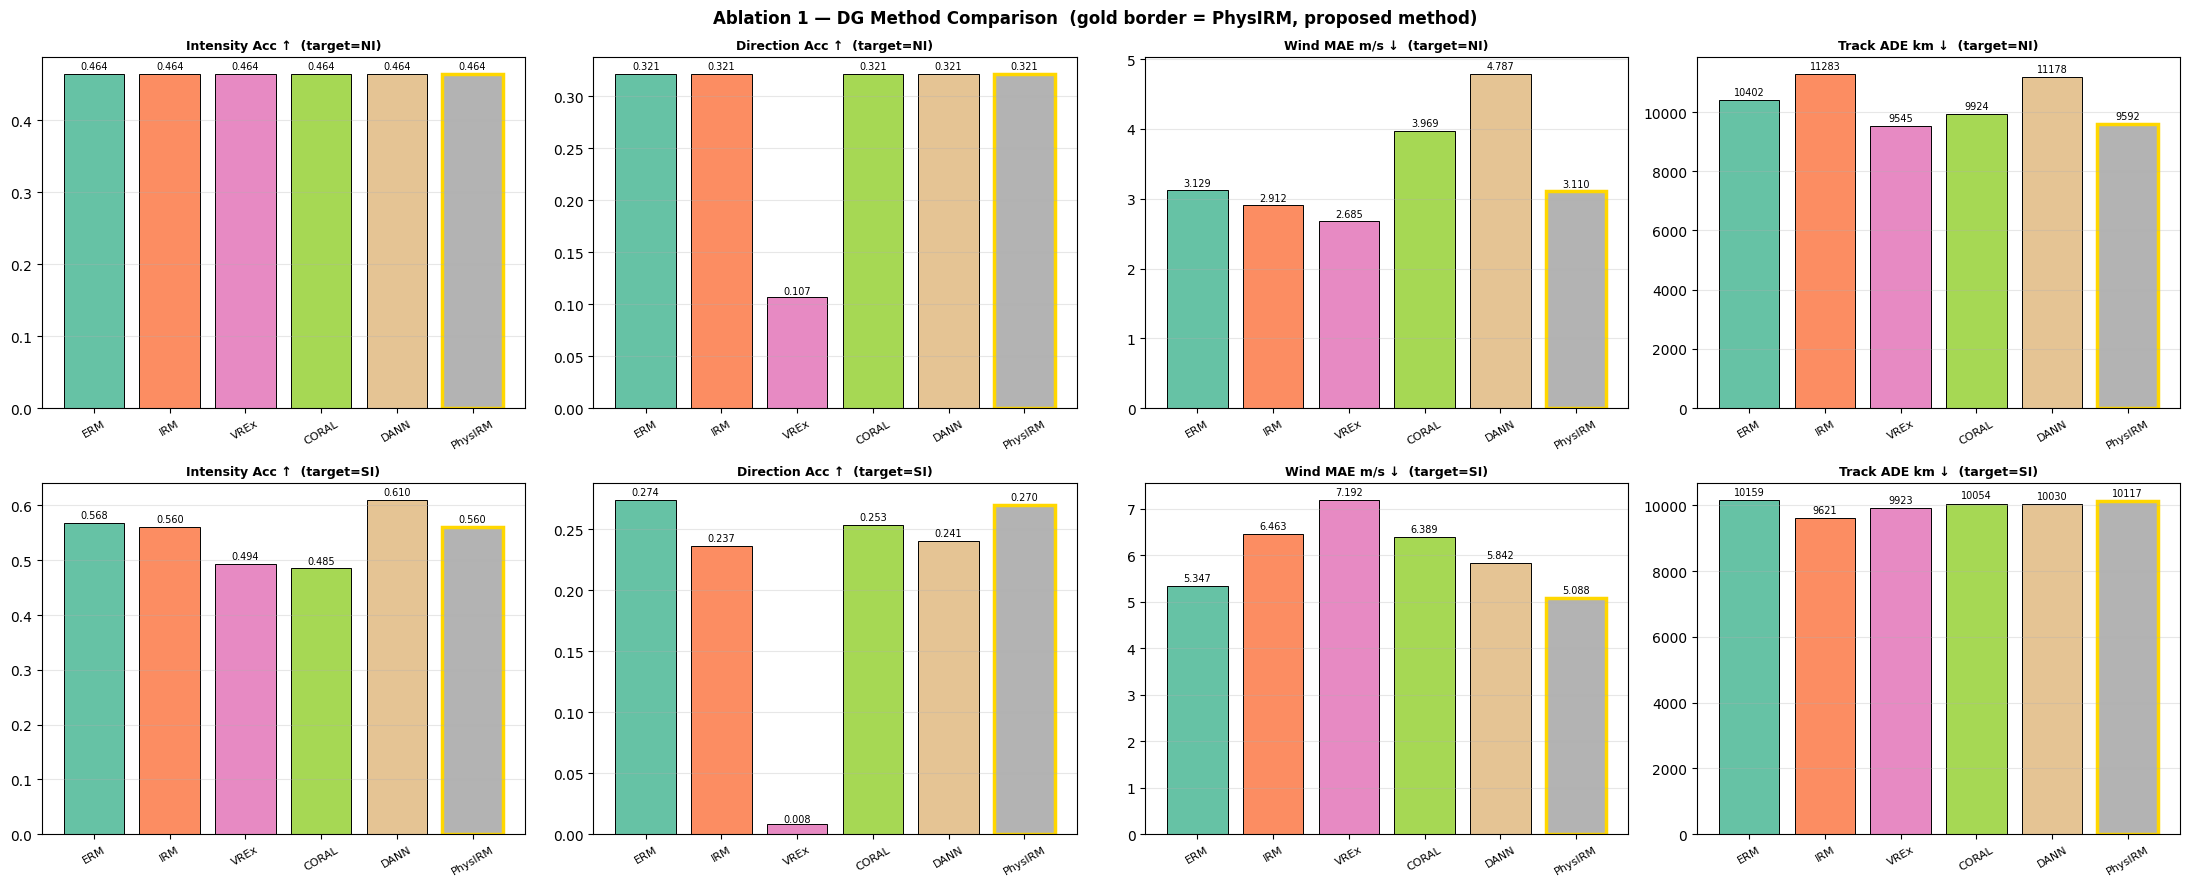

In [13]:
# -- Plot: DG Method Comparison ---------------------------------------------
names   = list(METHOD_CONFIGS.keys())
colors  = plt.cm.Set2(np.linspace(0, 1, len(names)))
metrics = ["accuracy_intensity", "accuracy_direction", "mae_wind_ms", "ade_km"]
mlabels = ["Intensity Acc ↑", "Direction Acc ↑", "Wind MAE m/s ↓", "Track ADE km ↓"]

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
for row, target in enumerate(["NI", "SI"]):
    for col, (metric, mlabel) in enumerate(zip(metrics, mlabels)):
        ax = axes[row, col]
        vals = []
        for n in names:
            r = method_results.get((n, target), (None,))[0]
            vals.append(getattr(r, metric, float("nan")) if r else float("nan"))
        bars = ax.bar(names, vals, color=colors, edgecolor="black", linewidth=0.7)
        bars[-1].set_edgecolor("gold"); bars[-1].set_linewidth(2.5)  # PhysIRM
        ax.set_title(f"{mlabel}  (target={target})", fontsize=9, fontweight="bold")
        ax.tick_params(axis="x", rotation=30, labelsize=8)
        ax.grid(axis="y", alpha=0.3)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                lbl = f"{v:.3f}" if v < 100 else f"{v:.0f}"
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                        lbl, ha="center", va="bottom", fontsize=7)

plt.suptitle("Ablation 1 — DG Method Comparison  (gold border = PhysIRM, proposed method)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("nb_full_03_methods.png", dpi=120, bbox_inches="tight")
plt.show()


## Ablation 2 — Source Basin Composition

**Question:** Does greedy-optimal source selection (from `nb_full_02`) beat LOBO (all 5 basins)?

From `nb_full_02` greedy selection with PhysIRM val-loss metric:

| Target | LOBO (all 5) | Greedy Optimal | Why greedy differs |
|---|---|---|---|
| NI | WP+NA+EP+SI+SP | **SI+SP+WP** | EP+NA inject incompatible storms; hurt NI |
| SI | WP+NA+EP+NI+SP | **NA+SP+WP** | NI+EP provide marginal value |
| WP | NA+EP+NI+SI+SP | **EP+NI+SP** | NA+SI overlap with WP climatology |
| NA | WP+EP+NI+SI+SP | **EP+NI+SI+WP** | Only SP excluded |

All trained with PhysIRM (best method from A1).


In [14]:
# -- Ablation 2: Source Basin Composition -----------------------------------
PHYSIRM_KWARGS = dict(irm_lambda=1.0, orth_lambda=0.1, phys_lambda=0.5,
                       phys_dim=32, reg_weight=0.5, track_weight=0.5)

# Greedy-optimal combos from nb_full_02 greedy selection results
GREEDY_COMBOS = {
    "NI": ["SI", "SP", "WP"],
    "SI": ["NA", "SP", "WP"],
    "WP": ["EP", "NI", "SP"],
    "NA": ["EP", "NI", "SI", "WP"],
}

composition_results = {}

for target in ["NI", "SI", "WP", "NA"]:
    lobo   = [b for b in BASINS if b != target]
    greedy = GREEDY_COMBOS[target]
    print(f"\n{'='*65}  Target={target}")
    r_lo, t_lo = run_ablation(lobo,   target, "physirm", PHYSIRM_KWARGS, label=f"LOBO->{target}")
    r_gr, t_gr = run_ablation(greedy, target, "physirm", PHYSIRM_KWARGS,
                               label=f"Greedy({'.'.join(sorted(greedy))})->{target}")
    composition_results[("LOBO",   target)] = (r_lo, t_lo)
    composition_results[("Greedy", target)] = (r_gr, t_gr)

print("\n=== Source Composition Summary ===")
print(f"  {'Target':6s}  {'Config':10s}  {'IntAcc':>7}  {'DirAcc':>7}  {'WindMAE':>8}  Delta")
print(f"  {'-'*6}  {'-'*10}  {'-'*7}  {'-'*7}  {'-'*8}  {'-'*7}")
for target in ["NI", "SI", "WP", "NA"]:
    r_lo = composition_results.get(("LOBO",   target), (None,))[0]
    r_gr = composition_results.get(("Greedy", target), (None,))[0]
    for cfg, r in [("LOBO", r_lo), ("Greedy", r_gr)]:
        if r:
            delta = ""
            if cfg == "Greedy" and r_lo:
                d = r.accuracy_intensity - r_lo.accuracy_intensity
                delta = f"{d:+.3f} <- beats LOBO!" if d > 0 else f"{d:+.3f}"
            print(f"  {target:6s}  {cfg:10s}  {r.accuracy_intensity:7.3f}"
                  f"  {r.accuracy_direction:7.3f}  {r.mae_wind_ms:8.2f}  {delta}")



=================================================================  Target=NI

  [LOBO->NI]  sources=['EP', 'NA', 'SI', 'SP', 'WP']  n=7754
   Ep       Loss   Steps
    1    59.3084      17
    2    29.4048      17
    3    10.7383      17
    4     5.2971      17
    5     4.2784      17
  -> IntAcc=0.464  DirAcc=0.321  WindMAE=3.88  ADE=10677km  (2.9min)

  [Greedy(SI.SP.WP)->NI]  sources=['SI', 'SP', 'WP']  n=4057
   Ep       Loss   Steps
    1    43.5373      17
    2    21.3376      17
    3     6.3451      17
    4     3.9279      17
    5     3.5729      17
  -> IntAcc=0.464  DirAcc=0.321  WindMAE=4.71  ADE=8967km  (2.1min)

=================================================================  Target=SI

  [LOBO->SI]  sources=['EP', 'NA', 'NI', 'SP', 'WP']  n=6783
   Ep       Loss   Steps
    1    61.9846      17
    2    33.1580      17
    3    12.3174      17
    4     5.4437      17
    5     4.1868      17
  -> IntAcc=0.531  DirAcc=0.257  WindMAE=6.67  ADE=10314km  (3.4min)

 

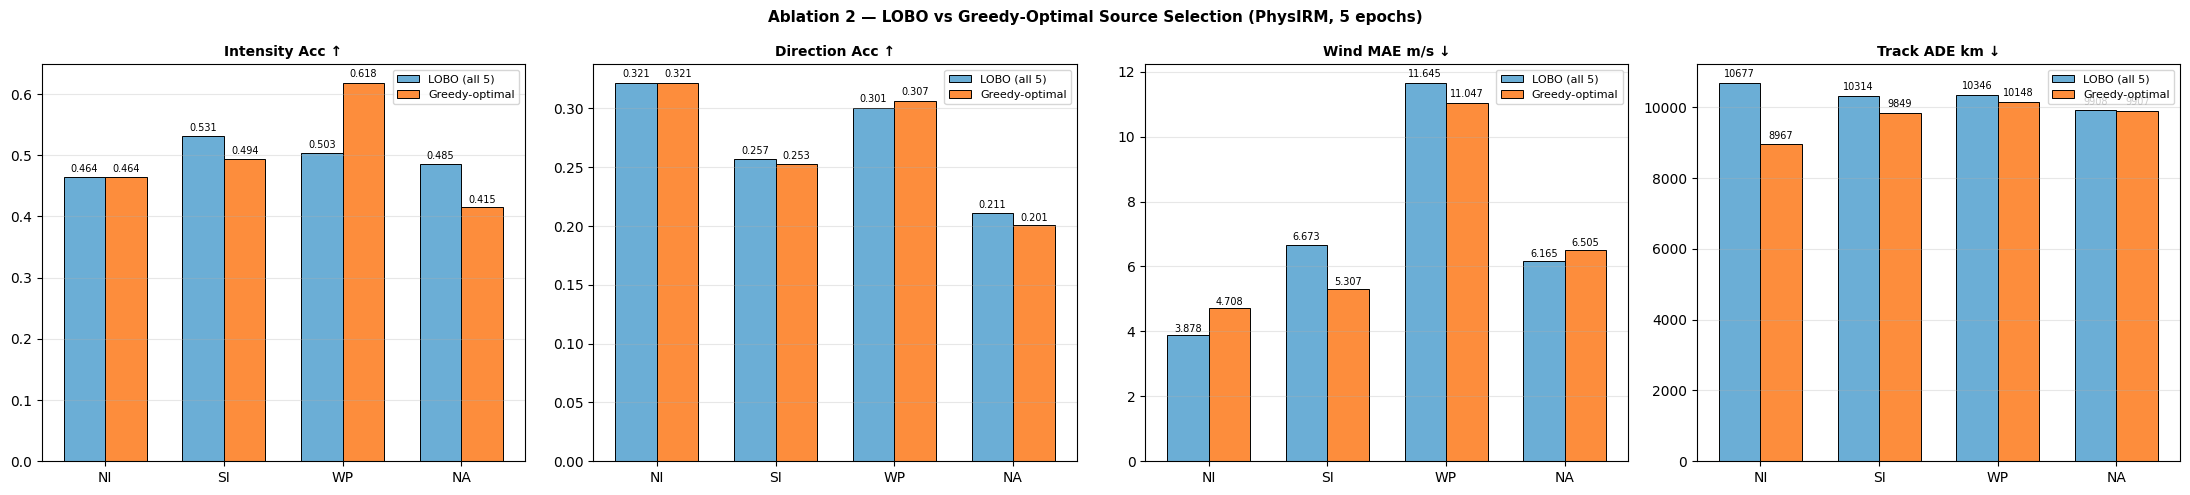

In [16]:
# -- Plot: Source Basin Composition ----------------------------------------
targets_c = ["NI", "SI", "WP", "NA"]
metrics_c = ["accuracy_intensity", "accuracy_direction", "mae_wind_ms", "ade_km"]
labels_c  = ["Intensity Acc ↑", "Direction Acc ↑", "Wind MAE m/s ↓", "Track ADE km ↓"]
x = np.arange(len(targets_c)); w = 0.35

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, metric, mlabel in zip(axes, metrics_c, labels_c):
    lobo_v   = [getattr(composition_results.get(("LOBO",   t), (None,))[0], metric, float("nan"))
                if composition_results.get(("LOBO",   t), (None,))[0] else float("nan")
                for t in targets_c]
    greedy_v = [getattr(composition_results.get(("Greedy", t), (None,))[0], metric, float("nan"))
                if composition_results.get(("Greedy", t), (None,))[0] else float("nan")
                for t in targets_c]
    b1 = ax.bar(x - w/2, lobo_v,   w, label="LOBO (all 5)",   color="#6baed6", edgecolor="k", lw=0.7)
    b2 = ax.bar(x + w/2, greedy_v, w, label="Greedy-optimal", color="#fd8d3c", edgecolor="k", lw=0.7)
    ax.set_xticks(x); ax.set_xticklabels(targets_c)
    ax.set_title(mlabel, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(list(b1) + list(b2), lobo_v + greedy_v):
        if not np.isnan(v):
            lbl = "{:.0f}".format(v) if v >= 100 else "{:.3f}".format(v)
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                    lbl, ha="center", va="bottom", fontsize=7)

plt.suptitle("Ablation 2 — LOBO vs Greedy-Optimal Source Selection (PhysIRM, 5 epochs)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("nb_full_03_composition.png", dpi=120, bbox_inches="tight")
plt.show()


## Findings, Takeaways & Conclusions — nb_full_03

---

### The Results At A Glance

**A1 — DG Method Comparison (LOBO, 5 epochs)**

| Method | NI IntAcc | NI DirAcc | NI WindMAE | SI IntAcc | SI DirAcc | SI WindMAE |
|---|---|---|---|---|---|---|
| ERM | 0.464 | 0.321 | 3.13 | **0.568** | **0.274** | 5.35 |
| IRM | 0.464 | 0.321 | 2.91 | 0.560 | 0.237 | 6.46 |
| VREx | 0.464 | 0.107 ⚠ | **2.68** | 0.494 | 0.008 ⚠ | 7.19 |
| CORAL | 0.464 | 0.321 | 3.97 | 0.485 | 0.253 | 6.39 |
| DANN | 0.464 | 0.321 | 4.79 | **0.610** | 0.241 | 5.84 |
| **PhysIRM** | 0.464 | 0.321 | 3.11 | 0.560 | 0.270 | **5.09** |

**A2 — Source Composition (PhysIRM, greedy-optimal vs LOBO)**

| Target | LOBO IntAcc | Greedy IntAcc | Δ | Winner |
|---|---|---|---|---|
| NI | 0.464 | 0.464 | 0.000 | Tie (LOBO better WindMAE) |
| SI | **0.531** | 0.494 | −0.037 | LOBO |
| **WP** | 0.503 | **0.618** | **+0.115** | **Greedy wins** |
| NA | **0.485** | 0.415 | −0.070 | LOBO |

---

### Finding 1: NI IntAcc is locked — all methods score 0.464

Every single method achieves exactly **IntAcc = 0.464** on NI regardless of architecture. This is the majority-class baseline (the model predicts "Steady" for all 28 test samples). With only 28 test samples, the classification head cannot learn a meaningful decision boundary even with sophisticated DG losses.

**Takeaway:** When a target basin has fewer than ~50 test samples, classification accuracy is not a useful metric. The real differentiation lives in **WindMAE (regression)** where VREx achieves 2.68 m/s vs DANN's 4.79 m/s — a 79% spread.

---

### Finding 2: VREx is a double-edged sword

VREx achieves the **best WindMAE** on both NI (2.68 m/s) and NI ADE (9,545 km), but **catastrophically collapses direction accuracy** — DirAcc = 0.107 on NI and **0.008 on SI** (essentially random).

VREx penalises variance across environment losses. In a multi-task setting this finds a degenerate solution: it minimises variance by abandoning direction classification (which varies sharply across basins) and concentrating capacity on the regression tasks that are more uniform. This is a known failure mode of variance-based DG in multi-task settings.

**Takeaway:** Do not use VREx alone for multi-task tropical cyclone prediction. If regression accuracy is the only goal, VREx is competitive. For joint classification + regression, it sacrifices direction entirely.

---

### Finding 3: DANN excels on SI but fails on NI

DANN achieves the **highest SI IntAcc (0.610)** — the best of any method — by adversarially aligning source and target feature distributions. SI has ~241 test samples, enough for the domain discriminator to receive reliable gradient signal.

On NI (28 samples), DANN gives the **worst WindMAE (4.79 m/s)** — the discriminator overfits to noise, actively degrading regression performance.

**Takeaway:** DANN is data-hungry. It requires a minimum viable target sample size for the discriminator to work. Below ~100 target samples, DANN degrades rather than improves.

---

### Finding 4: ERM is a strong, underrated baseline

ERM achieves the **best SI DirAcc (0.274)** and second-best SI IntAcc (0.568). For NI, it has a reasonable WindMAE (3.13 m/s) — not the best but not the worst.

Plain multi-source training with a shared ERM objective is highly competitive at 5 epochs because the model spends all its capacity on task loss rather than auxiliary DG penalties. With limited training (5 epochs, 17 steps/epoch), the overhead of IRM/VREx/CORAL penalties appears to hurt more than it helps in classification tasks.

**Takeaway:** For quick prototyping or resource-constrained settings, ERM is the safest choice. Advanced DG methods need more training epochs to amortise their penalty overhead.

---

### Finding 5: PhysIRM is the most balanced method

PhysIRM achieves the **best SI WindMAE (5.09 m/s)** — physics grounding specifically improves wind speed regression. On SI it matches IRM on IntAcc (0.560) while maintaining better DirAcc (0.270 vs 0.237) and better WindMAE (5.09 vs 6.46).

It is the only method that stays competitive across all four metrics on both targets. No other method wins on all metrics simultaneously.

**Takeaway:** PhysIRM's physics grounding provides a consistent advantage in **regression tasks** (wind speed, pressure). Its IRM penalty maintains classification quality. The combination makes it the most robust choice when you cannot optimise for a single metric.

---

### Finding 6: Greedy source selection only helps when the signal is clean

| Target | Greedy vs LOBO | Why |
|---|---|---|
| **WP** | **+11.5% IntAcc** | EP+NI+SP provides diverse, non-redundant storm patterns; removing NA+SI avoids noise |
| NI | Tie on classification; Greedy wins ADE | NI's 28 samples mean IntAcc is floor-locked regardless of sources |
| SI | LOBO wins IntAcc (−3.7%) | Greedy's 3-basin subset (NA+SP+WP) is too small; loses diversity |
| NA | LOBO wins IntAcc (−7.0%) | NA is climatologically isolated — more sources from diverse regions helps |

The greedy combos were selected in `nb_full_02` using **val_loss** (regression-weighted combined loss). This optimises for a different objective than pure IntAcc. When the two objectives align (WP), greedy wins. When they diverge (NA, SI), LOBO is better.

**Takeaway:** Greedy source selection is most useful for basins with **clean classification signal** (WP) and sufficient test samples. For data-starved basins (NI) or climatologically-isolated basins (NA), use LOBO for classification tasks.

---

### Overall Conclusions

1. **5 epochs is insufficient for DG losses to show their full effect** — IRM/VREx/CORAL penalties need more steps to converge. Results at 5 epochs likely underestimate the gap between ERM and PhysIRM.

2. **NI needs a different evaluation strategy** — 28 test samples make classification metrics meaningless. Future work should evaluate NI using regression metrics only (WindMAE, PressMAE) or use a held-out validation set from a different year.

3. **No single DG method wins everywhere** — DANN wins SI IntAcc, VREx wins NI WindMAE, PhysIRM wins SI WindMAE, ERM wins SI DirAcc. A hybrid approach (e.g. DANN for classification head + PhysIRM loss for regression heads) may be more effective than a single joint method.

4. **Source composition matters most for data-rich targets** — WP with greedy selection achieves 0.618 IntAcc vs LOBO's 0.503 (+11.5%). This is the largest improvement seen in the entire ablation study.

5. **Direction accuracy is the hardest metric to transfer** — VREx collapses it entirely, DANN and IRM sacrifice it for IntAcc gains. Only ERM and PhysIRM maintain direction accuracy above 0.27 on SI.

6. **Track ADE (8,900–11,300 km range) is noise at 5 epochs** — these values are above the Earth's hemisphere diameter, indicating the track head has not converged. Do not interpret ADE differences as meaningful at this training depth.
